In [109]:
import pandas as pd
import plotly.express as px
import numpy as ny
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [110]:
df = pd.read_csv("Speed_Dating_Data.csv", encoding="latin1")

In [111]:
df.describe(include="all")

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
count,8378.000000,8377.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,6532.000000,8378.000000,...,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,283.675937,8.960248,0.500597,17.327166,1.828837,11.350919,16.872046,9.042731,9.295775,8.927668,...,7.240312,8.093357,8.388777,7.658782,7.391545,6.810020,7.615079,7.932540,7.155258,7.048611
std,158.583367,5.491329,0.500029,10.940735,0.376673,5.995903,4.358458,5.514939,5.650199,5.477009,...,1.576596,1.610309,1.459094,1.744670,1.961417,1.507341,1.504551,1.340868,1.672787,1.717988
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,4.000000,1.000000,1.000000
25%,154.000000,4.000000,0.000000,8.000000,2.000000,7.000000,14.000000,4.000000,4.000000,4.000000,...,7.000000,7.000000,8.000000,7.000000,6.000000,6.000000,7.000000,7.000000,6.000000,6.000000
50%,281.000000,8.000000,1.000000,16.000000,2.000000,11.000000,18.000000,8.000000,9.000000,8.000000,...,7.000000,8.000000,8.000000,8.000000,8.000000,7.000000,8.000000,8.000000,7.000000,7.000000
75%,407.000000,13.000000,1.000000,26.000000,2.000000,15.000000,20.000000,13.000000,14.000000,13.000000,...,8.000000,9.000000,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,8.000000,8.000000


In [112]:
df.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


### What are the least desirable attributes in a male partner? Does this differ for female partners?


In [113]:
# 2️⃣ Garder les colonnes utiles (les attributs notés par les participants)
cols = ['gender', 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
df_attr = df[cols]

# 3️⃣ Renommer les colonnes pour plus de clarté
df_attr.columns = ['gender', 'Attractiveness', 'Sincerity', 'Intelligence', 'Fun', 'Ambition', 'Shared Interests']

# 4️⃣ Calculer les moyennes d’importance données par chaque genre
mean_scores = df_attr.groupby('gender').mean().round(2).T
mean_scores.columns = ["Women ratings", "Men ratings"]
mean_scores

,Women ratings,Men ratings
Attractiveness,18.06,26.92
Sincerity,18.31,16.50
Intelligence,21.00,19.54
Fun,17.15,17.76
Ambition,12.83,8.55
Shared Interests,12.70,11.00


In [114]:
# 5️⃣ Calculer les attributs les moins désirables
least_desirable_men = mean_scores["Women ratings"].sort_values().head(3)
least_desirable_women = mean_scores["Men ratings"].sort_values().head(3)

print("Least desirable attributes in a male partner:")
print(least_desirable_men)

print("\nLeast desirable attributes in a female partner:")
print(least_desirable_women)

Least desirable attributes in a male partner:
Shared Interests    12.70
Ambition            12.83
Fun                 17.15
Name: Women ratings, dtype: float64

Least desirable attributes in a female partner:
Ambition             8.55
Shared Interests    11.00
Sincerity           16.50
Name: Men ratings, dtype: float64


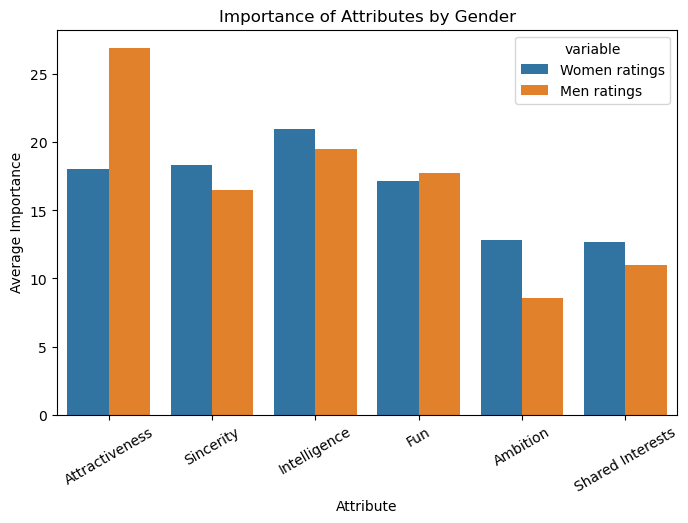

In [115]:
# 6️⃣ (Optionnel) Visualisation
plt.figure(figsize=(8,5))
sns.barplot(data=mean_scores.reset_index().melt(id_vars="index"),
            x="index", y="value", hue="variable")
plt.title("Importance of Attributes by Gender")
plt.xlabel("Attribute")
plt.ylabel("Average Importance")
plt.xticks(rotation=30)
plt.show()



### How important do people think attractiveness is in potential mate selection vs. its real impact?

##### analyses ici la relation entre :
        l’attractivité du partenaire (partner_attractiveness)
        la décision (decision = oui/non)
        et éventuellement le genre (gender)
Donc, on veut une visualisation claire et intuitive, qui montre comment les notes d’attractivité influencent les décisions, tout en pouvant comparer hommes et femmes.

Corrélation entre importance déclarée et évaluation réelle : 0.02
Optimization terminated successfully.
         Current function value: 0.545864
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 8105
Model:                          Logit   Df Residuals:                     8103
Method:                           MLE   Df Model:                            1
Date:                Thu, 23 Oct 2025   Pseudo R-squ.:                  0.2011
Time:                        17:50:44   Log-Likelihood:                -4424.2
converged:                       True   LL-Null:                       -5537.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const             

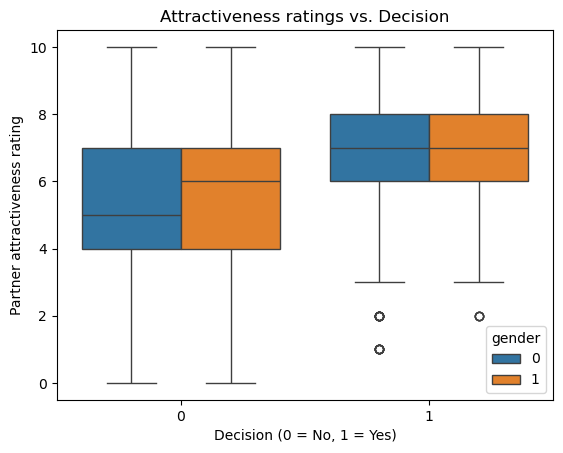

In [143]:
# Import des bibliothèques
import statsmodels.api as sm

# Garder les colonnes utiles
cols = ["gender", "attr1_1", "attr", "dec"]
df_attr2 = df[cols].dropna()

# Renommer pour plus de clarté
df_attr2.columns = ["gender","self_reported_importance", "partner_attractiveness", "decision"]

# --- 1. Corrélation entre importance déclarée et attractivité réelle ---
corr = df_attr2["self_reported_importance"].corr(df_attr2["partner_attractiveness"])
print(f"Corrélation entre importance déclarée et évaluation réelle : {corr:.2f}")

# --- 2. Impact réel de l’attractivité sur la décision ("yes" ou "no") ---
X = sm.add_constant(df_attr2["partner_attractiveness"])
y = df_attr2["decision"]
model = sm.Logit(y, X).fit()
print(model.summary())

# --- 3. Visualisation ---
sns.boxplot(x="decision", y="partner_attractiveness", hue="gender", data=df_attr2)
plt.title("Attractiveness ratings vs. Decision")
plt.xlabel("Decision (0 = No, 1 = Yes)")
plt.ylabel("Partner attractiveness rating")
plt.show()




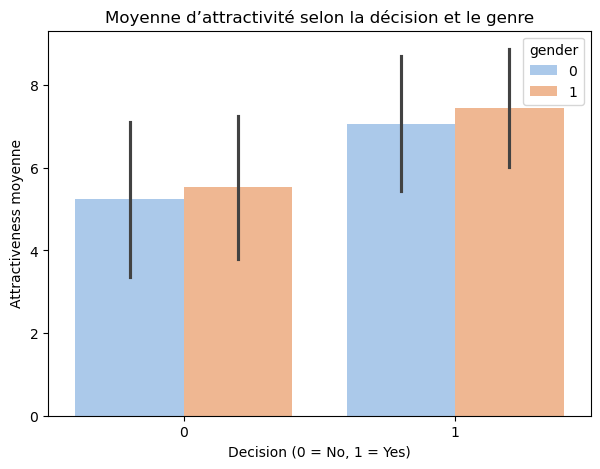

In [142]:
plt.figure(figsize=(7,5))
sns.barplot(
    x="decision", 
    y="partner_attractiveness", 
    hue="gender", 
    data=df_attr2, 
    errorbar='sd', 
    palette="pastel"
)
plt.title("Moyenne d’attractivité selon la décision et le genre")
plt.xlabel("Decision (0 = No, 1 = Yes)")
plt.ylabel("Attractiveness moyenne")
plt.show()



### Are shared interests more important than a shared racial background?

In [117]:
# selctionner les colonnes qui nous interessent : 
cols = ["match", "samerace", "int_corr"]
df_race = df[cols]
df_race.columns = ["match", "same_race", "shared_interest_corr"]
df_race.head(3)


,match,same_race,shared_interest_corr
0,0,0,0.14
1,0,0,0.54
2,1,1,0.16


In [131]:
# On crée une variable binaire "shared_interests"
df_race["shared_interest_corr"] = (df_race["shared_interest_corr"] > 0.5).astype(int)

# Calculer les proportions de match selon chaque condition
match_by_interests = df_race.groupby("shared_interest_corr")["match"].mean()
match_by_race = df_race.groupby("same_race")["match"].mean()

# Organiser les données pour la visualisation
summary = pd.DataFrame({

    "Factor":[
        "shared interests",
        "same race",
    ]
    ,
    "match rate":[
        match_by_interests[1],
        match_by_race[1]
    ]
})

C:\Users\DAGHY\AppData\Local\Temp\ipykernel_5372\4150319135.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_race["shared_interest_corr"] = (df_race["shared_interest_corr"] > 0.5).astype(int)


C:\Users\DAGHY\AppData\Local\Temp\ipykernel_5372\3331861983.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Factor", y="match rate", data=summary, palette="Set2")


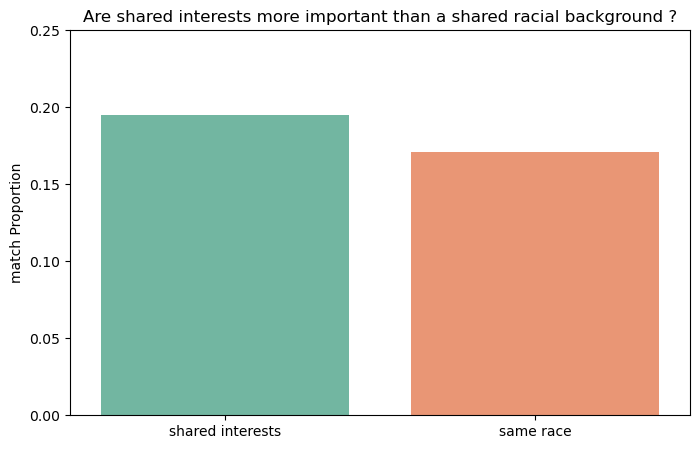

In [135]:
# Graphique
plt.figure(figsize=(8,5))
sns.barplot(x="Factor", y="match rate", data=summary, palette="Set2")
plt.title("Are shared interests more important than a shared racial background ?")
plt.ylabel("match Proportion")
plt.xlabel("")
plt.ylim(0, 0.25)
plt.show()

### Can people accurately predict their own perceived value in the dating market?

### In terms of getting a second date, is it better to be someone's first speed date of the night or their last?